In [ ]:
import torch
import torchmetrics
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import torch.utils.data as data
import random
from tqdm import tqdm
from matplotlib import pyplot as plt

In [231]:
seed = 200

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [232]:
train_data = pd.read_csv('train_data.csv')
train_data['SalePrice'] = pd.cut(train_data['SalePrice'], bins=[0, 100000, 350000, float('inf')], labels=[0, 1, 2])

train = train_data.sample(frac=0.8, random_state=seed)
remaining = train_data.drop(train.index)
val = remaining.sample(frac=0.5, random_state=seed)
test = remaining.drop(val.index)

y_train = train.pop('SalePrice')
y_val = val.pop('SalePrice')
y_test = test.pop('SalePrice')

train = pd.get_dummies(train)
val = pd.get_dummies(val)
test = pd.get_dummies(test)

print(f"Train shape: {train.shape}")
print(f"Val shape: {val.shape}")
print(f"Test shape: {test.shape}")


Train shape: (3299, 33)
Val shape: (412, 33)
Test shape: (413, 33)


In [233]:
train_dataset = data.TensorDataset(torch.from_numpy(train.astype(float).values).float(), torch.from_numpy(y_train.values.astype(int)))
val_dataset = data.TensorDataset(torch.from_numpy(val.astype(float).values).float(), torch.from_numpy(y_val.values.astype(int)))
test_dataset = data.TensorDataset(torch.from_numpy(test.astype(float).values).float(), torch.from_numpy(y_test.values.astype(int)))

In [234]:
batch_size = 64

train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

loaders = {
    'train': train_dataloader,
    'val': val_dataloader,
    'test': test_dataloader
}

In [235]:
class Model(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lin1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)

        self.lin2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)

        self.lin3 = nn.Linear(32, 3)

        self.act = nn.ReLU()
    
    def forward(self, x):
        x = self.lin1(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.lin2(x)
        x = self.bn2(x)
        x = self.act(x)
        
        x = self.lin3(x)

        return x

In [236]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [237]:
model = Model(train.shape[1]).to(device)

class_counts = np.bincount(y_train.values.astype(int))
weights = torch.FloatTensor(1.0 / class_counts).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [238]:
def training(model, loaders, criterion, optimizer, epochs, with_plot):

    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task='multiclass', num_classes=3, average='macro').to(device)
    
    iters, train_loss, val_loss, train_acc, val_acc = [], [], [], [], []
    
    for epoch in range(1, epochs + 1):
        iters.append(epoch)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            for X_batch, target in tqdm(loaders[phase]):
                X_batch, target = X_batch.to(device), target.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    preds = model(X_batch)
                    loss = criterion(preds, target)

                    metric_loss(loss)
                    metric_acc(preds, target)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
            
            acc = metric_acc.compute().item()
            mean_loss = metric_loss.compute().item()
            
            print(f"[{phase}] {epoch}/{epochs}, Loss: {mean_loss}, Accuracy: {acc}")

            if phase == 'train':
                train_loss.append(mean_loss)
                train_acc.append(acc)
            else:
                val_loss.append(mean_loss)
                val_acc.append(acc)

            metric_loss.reset()
            metric_acc.reset()

    if with_plot:
        plt.figure(figsize=(10,4))

        plt.subplot(1, 2, 1)
        plt.title("Train/Eval Loss")
        plt.plot(iters, train_loss, label="Train")
        plt.plot(iters, val_loss, label="Validation")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")

        plt.subplot(1, 2, 2)
        plt.title("Train/Eval Accuracy")
        plt.plot(iters, train_acc, label="Train")
        plt.plot(iters, val_acc, label="Validation")
        plt.xlabel("Iterations")
        plt.ylabel("Accuracy")
        plt.legend(loc='best')

        plt.show()


100%|██████████| 52/52 [00:00<00:00, 133.98it/s]


[train] 1/75, Loss: 0.8511132597923279, Accuracy: 0.7068398594856262


100%|██████████| 7/7 [00:00<00:00, 194.20it/s]


[val] 1/75, Loss: 0.7322373986244202, Accuracy: 0.7697283029556274


100%|██████████| 52/52 [00:00<00:00, 144.56it/s]


...

[val] 74/75, Loss: 0.27765601873397827, Accuracy: 0.8899362087249756


100%|██████████| 52/52 [00:00<00:00, 134.29it/s]


[train] 75/75, Loss: 0.3243371844291687, Accuracy: 0.879108190536499


100%|██████████| 7/7 [00:00<00:00, 198.45it/s]

[val] 75/75, Loss: 0.2760077118873596, Accuracy: 0.8885927200317383


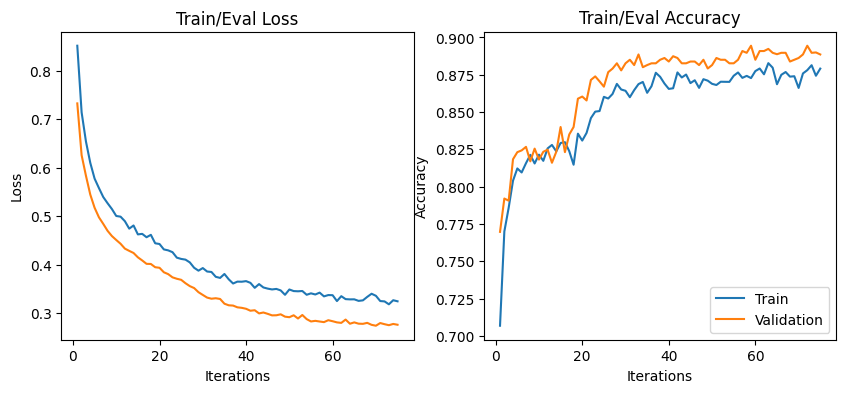

In [239]:
training(model, loaders, criterion, optimizer, 75, True)

In [240]:
model.eval()
preds_l, targets_l = [], []

for X_batch, target in test_dataloader:
    X_batch, target = X_batch.to(device), target.to(device)

    with torch.inference_mode():
        preds = model(X_batch)
        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

preds = np.argmax(np.array(preds_l), axis=1)
targets = np.array(targets_l)

array([[<Axes: title={'center': 'targets'}>]], dtype=object)

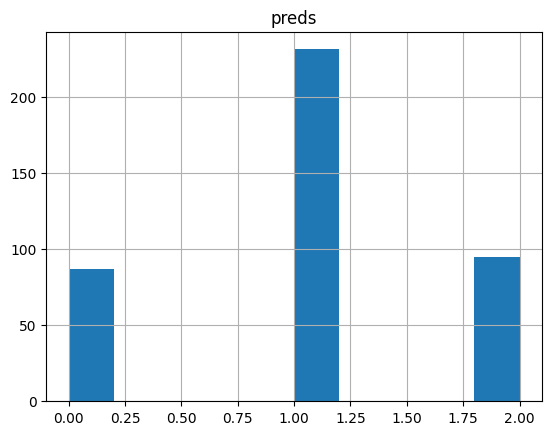

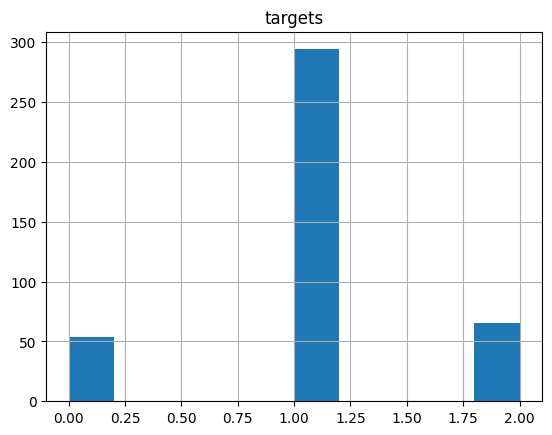

In [241]:
pd.DataFrame(preds, columns=["preds"]).astype(int).hist()
pd.DataFrame(targets.squeeze(), columns=["targets"]).astype(int).hist()

In [242]:
def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct=(pred_targets == targets.values)[targets == i].sum()
        accuracies.append(class_correct/(targets == i).sum())
    return(np.mean(accuracies))

In [243]:
print(calc_accuracy(pd.Series(preds), pd.Series(targets)))

0.9097854526425956


In [244]:
test_data = pd.read_csv('test_data.csv')
test = pd.get_dummies(test_data)
print(f"Test shape: {test.shape}")

X_test = torch.from_numpy(test.astype(float).values).float().to(device)
model.eval()
with torch.inference_mode():
    preds = model(X_test)
    preds = torch.argmax(preds, dim=1).cpu().numpy()

pd.DataFrame(preds).to_csv('pred.csv', index=False, header=False)

Test shape: (1767, 33)
